# Verificador LTL con Autómatas de Büchi
## *Model Checking de Sistemas Reactivos*

**Proyecto Final · Teoría de Autómatas · Jorge Vasquez**

La verificación formal de sistemas reactivos es uno de los problemas centrales de la informática teórica: dado un sistema que opera de forma indefinida y una especificación de comportamiento, ¿puede garantizarse *matemáticamente* que el sistema satisface dicha especificación en la totalidad de sus ejecuciones posibles, incluyendo aquellas de longitud infinita?

Este proyecto implementa un **verificador de modelos** (*model checker*) completo basado en **Autómatas de Büchi** — el modelo formal de cómputo diseñado específicamente para razonar sobre lenguajes de palabras infinitas. El verificador recibe como entrada una descripción formal del sistema mediante una **Estructura de Kripke** y una propiedad de comportamiento expresada en **Lógica Temporal Lineal (LTL)**, y determina si la propiedad se satisface en la totalidad de los comportamientos del sistema.

Cuando la propiedad es violada, el verificador produce un **contraejemplo**: una traza concreta del sistema donde la propiedad falla, convirtiendo la verificación en una herramienta tanto de prueba como de diagnóstico automático.

### Fundamento teórico

El verificador descansa sobre el siguiente resultado clásico de la teoría de autómatas sobre palabras infinitas:

> Una propiedad LTL $\varphi$ puede codificarse como un Autómata de Büchi no determinista $A_\varphi$ tal que $\mathcal{L}(A_\varphi) = \{\sigma \in (2^{AP})^\omega \mid \sigma \models \varphi\}$.

De este resultado se deriva el criterio de verificación: un sistema $M$ **satisface** $\varphi$ si y solo si no existe ninguna traza del producto $M \times A_{\neg\varphi}$ que sea aceptada por el Büchi, lo cual es equivalente a la ausencia de un **ciclo aceptante** en dicho producto:

$$M \models \varphi \iff \mathcal{L}(M) \cap \mathcal{L}(A_{\neg\varphi}) = \emptyset$$

La búsqueda de ese ciclo es el problema resuelto por el algoritmo **Nested DFS** (Holzmann et al., 1992), y la conversión LTL → Büchi es realizada por el algoritmo **GPVW** (Gerth, Peled, Vardi, Wolper, 1995).

### Pipeline del verificador

```
Sistema (Kripke M)   +   Propiedad φ (LTL)
          │                       │
          │                 Negar: ¬φ
          │                       │
          │         GPVW: ¬φ → Büchi A_{¬φ}
          │                       │
          └────── Producto M × A ─┘
                         │
             Nested DFS: ¿existe ciclo aceptante?
                         │
          ┌──────────────┴──────────────┐
    ✅ Verificado                  ❌ Violado
                               + contraejemplo
```

### Estructura del notebook

El notebook se organiza en nueve módulos de implementación seguidos de cuatro ejemplos de verificación con análisis formal:

| Sección | Contenido |
|---|---|
| Módulos 1–2 | Sintaxis LTL: AST y parser recursivo descendente |
| Módulo 3 | Autómata de Büchi: definición e implementación |
| Módulos 4–4B | Conversión LTL → Büchi: construcciones directas y algoritmo GPVW |
| Módulo 5 | Estructura de Kripke: modelo del sistema |
| Módulo 6 | Autómata producto $M \times A$: construcción *on-the-fly* |
| Módulo 7 | Nested DFS: detección de ciclos aceptantes |
| Módulo 8 | Función `verify()`: pipeline completo |
| Módulo 9 | Visualizaciones con networkx y matplotlib |
| Ejemplos 1–4 | Verificación de cuatro sistemas con análisis formal de resultados |

In [1]:
# ── Dependencias ──────────────────────────────────────────────
import re
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Set, Dict, List, Tuple, FrozenSet, Optional

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

## Módulo 1: Árbol de Sintaxis Abstracta (AST) para LTL

La **Lógica Temporal Lineal (LTL)** fue introducida por Pnueli (1977) para especificar propiedades de sistemas reactivos sobre secuencias infinitas de estados. La sintaxis de LTL se define inductivamente sobre un conjunto de **proposiciones atómicas** $AP$:

$$\varphi ::= p \;\mid\; \neg\varphi \;\mid\; \varphi \wedge \psi \;\mid\; \varphi \vee \psi \;\mid\; \mathbf{G}\,\varphi \;\mid\; \mathbf{F}\,\varphi$$

donde $p \in AP$. Los operadores temporales se interpretan sobre trazas infinitas $\sigma = s_0 s_1 s_2 \ldots$:

| Fórmula | Semántica |
|---|---|
| $p$ | $p \in L(s_0)$ — la proposición es verdadera en el estado actual |
| $\neg\varphi$ | $\sigma \not\models \varphi$ |
| $\varphi \wedge \psi$ | $\sigma \models \varphi$ y $\sigma \models \psi$ |
| $\mathbf{G}\,\varphi$ | $\forall i \geq 0,\; \sigma^i \models \varphi$ — $\varphi$ es verdadera **siempre** |
| $\mathbf{F}\,\varphi$ | $\exists i \geq 0,\; \sigma^i \models \varphi$ — $\varphi$ es verdadera **eventualmente** |

donde $\sigma^i = s_i s_{i+1} \ldots$ denota el sufijo de $\sigma$ a partir de la posición $i$.

La implementación representa cada fórmula como un nodo de un **árbol de sintaxis abstracta (AST)**: cada clase Python corresponde a un operador o a una proposición atómica, formando una jerarquía de tipos que preserva la estructura recursiva de la gramática.

| Clase | Operador | Representación |
|---|---|---|
| `Atom(p)` | — | proposición atómica $p$ |
| `Not(φ)` | `!` | negación $\neg\varphi$ |
| `And(φ,ψ)` | `&` | conjunción $\varphi \wedge \psi$ |
| `Or(φ,ψ)` | `\|` | disyunción $\varphi \vee \psi$ |
| `G(φ)` | `G` | globally $\mathbf{G}\,\varphi$ |
| `F(φ)` | `F` | finally $\mathbf{F}\,\varphi$ |

In [2]:
# ── AST de Fórmulas LTL ───────────────────────────────────────

class Formula:
    """Clase base para todas las fórmulas LTL."""
    pass

class Atom(Formula):
    def __init__(self, name: str):
        self.name = name
    def __repr__(self): return self.name
    def __eq__(self, o): return isinstance(o, Atom) and self.name == o.name
    def __hash__(self): return hash(('Atom', self.name))

class Not(Formula):
    def __init__(self, child: Formula):
        self.child = child
    def __repr__(self): return f'!{self.child}'
    def __eq__(self, o): return isinstance(o, Not) and self.child == o.child
    def __hash__(self): return hash(('Not', self.child))

class And(Formula):
    def __init__(self, left: Formula, right: Formula):
        self.left, self.right = left, right
    def __repr__(self): return f'({self.left} & {self.right})'
    def __eq__(self, o): return isinstance(o, And) and self.left == o.left and self.right == o.right
    def __hash__(self): return hash(('And', self.left, self.right))

class Or(Formula):
    def __init__(self, left: Formula, right: Formula):
        self.left, self.right = left, right
    def __repr__(self): return f'({self.left} | {self.right})'
    def __eq__(self, o): return isinstance(o, Or) and self.left == o.left and self.right == o.right
    def __hash__(self): return hash(('Or', self.left, self.right))

class G(Formula):  # Globally / Always
    def __init__(self, child: Formula):
        self.child = child
    def __repr__(self): return f'G({self.child})'
    def __eq__(self, o): return isinstance(o, G) and self.child == o.child
    def __hash__(self): return hash(('G', self.child))

class F(Formula):  # Finally / Eventually
    def __init__(self, child: Formula):
        self.child = child
    def __repr__(self): return f'F({self.child})'
    def __eq__(self, o): return isinstance(o, F) and self.child == o.child
    def __hash__(self): return hash(('F', self.child))

print('✓ AST definido')

✓ AST definido


## Módulo 2: Parser LTL

El parser convierte una cadena de texto como `"G F verde"` o `"G !(critica_A & critica_B)"` en el árbol AST correspondiente. Se implementa como un **parser recursivo descendente** basado en la siguiente gramática libre de contexto:

$$\begin{align}
\langle\text{expr}\rangle  &\to \langle\text{or}\rangle \\
\langle\text{or}\rangle    &\to \langle\text{and}\rangle\; (\;\texttt{|}\; \langle\text{and}\rangle\;)^* \\
\langle\text{and}\rangle   &\to \langle\text{unary}\rangle\; (\;\texttt{\&}\; \langle\text{unary}\rangle\;)^* \\
\langle\text{unary}\rangle &\to \texttt{!}\,\langle\text{unary}\rangle \;\mid\; \texttt{G}\,\langle\text{unary}\rangle \;\mid\; \texttt{F}\,\langle\text{unary}\rangle \;\mid\; \texttt{(}\langle\text{expr}\rangle\texttt{)} \;\mid\; \langle\text{atom}\rangle
\end{align}$$

La precedencia resultante es: `!`, `G`, `F` (mayor) $>$ `&` $>$ `|` (menor), con soporte completo para agrupación mediante paréntesis.

El módulo incluye también la función `to_nnf`, que transforma cualquier fórmula LTL a su **Forma Normal Negativa (NNF)**: una representación equivalente donde todas las negaciones están aplicadas directamente sobre proposiciones atómicas. Las reglas de transformación son:

$$\neg\neg\varphi \;\to\; \varphi \qquad \neg\mathbf{G}\,\varphi \;\to\; \mathbf{F}\,\neg\varphi \qquad \neg\mathbf{F}\,\varphi \;\to\; \mathbf{G}\,\neg\varphi \qquad \neg(\varphi \wedge \psi) \;\to\; \neg\varphi \vee \neg\psi$$

La conversión a NNF es un prerequisito del algoritmo GPVW, que requiere que las negaciones estén normalizadas antes de iniciar la construcción del tableau.

In [3]:
# ── Parser LTL ────────────────────────────────────────────────

def tokenize(s: str) -> list:
    """Divide el string en tokens LTL."""
    return re.findall(r'G\b|F\b|!|&|\||\(|\)|[a-zA-Z_][a-zA-Z0-9_]*', s)

def parse_ltl(s: str) -> Formula:
    """
    Parsea una fórmula LTL desde string.
    Ejemplos: 'G F verde', 'G !(critica_A & critica_B)', 'F critica_A'
    """
    tokens = tokenize(s)
    pos = [0]

    def peek():
        return tokens[pos[0]] if pos[0] < len(tokens) else None

    def consume():
        t = tokens[pos[0]]; pos[0] += 1; return t

    def parse_expr(): return parse_or()

    def parse_or():
        left = parse_and()
        while peek() == '|':
            consume()
            left = Or(left, parse_and())
        return left

    def parse_and():
        left = parse_unary()
        while peek() == '&':
            consume()
            left = And(left, parse_unary())
        return left

    def parse_unary():
        t = peek()
        if t == '!': consume(); return Not(parse_unary())
        if t == 'G': consume(); return G(parse_unary())
        if t == 'F': consume(); return F(parse_unary())
        if t == '(':
            consume()
            e = parse_expr()
            consume()  # ')'
            return e
        return Atom(consume())

    return parse_expr()


# ── NNF: Forma Normal Negativa ─────────────────────────────────
# Empuja todas las negaciones hacia los átomos.
# Reglas: ¬¬φ→φ, ¬(φ&ψ)→(¬φ|¬ψ), ¬Gφ→F¬φ, ¬Fφ→G¬φ

def to_nnf(f: Formula) -> Formula:
    """Convierte fórmula a Forma Normal Negativa."""
    if isinstance(f, Atom):
        return f
    if isinstance(f, Not):
        c = f.child
        if isinstance(c, Atom):  return f
        if isinstance(c, Not):   return to_nnf(c.child)
        if isinstance(c, And):   return Or(to_nnf(Not(c.left)), to_nnf(Not(c.right)))
        if isinstance(c, Or):    return And(to_nnf(Not(c.left)), to_nnf(Not(c.right)))
        if isinstance(c, G):     return F(to_nnf(Not(c.child)))
        if isinstance(c, F):     return G(to_nnf(Not(c.child)))
    if isinstance(f, And): return And(to_nnf(f.left), to_nnf(f.right))
    if isinstance(f, Or):  return Or(to_nnf(f.left), to_nnf(f.right))
    if isinstance(f, G):   return G(to_nnf(f.child))
    if isinstance(f, F):   return F(to_nnf(f.child))
    return f


# ── Tests del parser ──────────────────────────────────────────
assert repr(parse_ltl('G F verde')) == 'G(F(verde))'
assert repr(parse_ltl('G !(a & b)')) == 'G(!(a & b))'
assert repr(to_nnf(Not(G(Atom('p'))))) == 'F(!p)'
assert repr(to_nnf(Not(F(Atom('p'))))) == 'G(!p)'
assert repr(to_nnf(Not(Not(Atom('p'))))) == 'p'
print('✓ Parser y NNF OK')

✓ Parser y NNF OK


## Módulo 3: Autómata de Büchi

Un **Autómata de Büchi no determinista (NBA)** generaliza los autómatas finitos al reconocimiento de *palabras infinitas* sobre alfabetos de la forma $\Sigma = 2^{AP}$. Formalmente se define como la tupla:

$$A = (Q,\; \Sigma,\; \delta,\; Q_0,\; F)$$

| Componente | Descripción |
|---|---|
| $Q$ | Conjunto finito de estados |
| $\Sigma = 2^{AP}$ | Alfabeto: conjuntos de proposiciones atómicas verdaderas |
| $\delta \subseteq Q \times \Sigma \times Q$ | Relación de transición no determinista |
| $Q_0 \subseteq Q$ | Conjunto de estados iniciales |
| $F \subseteq Q$ | Conjunto de estados de aceptación |

El **criterio de aceptación de Büchi** es la condición que distingue a estos autómatas de los autómatas finitos clásicos:

$$\rho = q_0 q_1 q_2 \ldots \text{ es aceptante} \iff \mathrm{Inf}(\rho) \cap F \neq \emptyset$$

donde $\mathrm{Inf}(\rho) = \{q \in Q \mid q \text{ aparece infinitamente a menudo en } \rho\}$.

Es decir, una ejecución es aceptada si y solo si **atraviesa infinitamente muchas veces** algún estado de $F$. A diferencia de los autómatas finitos, no basta con que la ejecución *termine* en un estado de aceptación — el sistema debe *retornar* a él de forma recurrente a lo largo de toda la traza infinita.

En la implementación, cada transición lleva asociada una **guardia**: un conjunto de literales (átomos o negaciones de átomos) que deben ser satisfechos por las etiquetas del estado de Kripke actual para que la transición esté habilitada. Esto permite representar de forma compacta el alfabeto exponencial $2^{AP}$.

In [4]:
# ── Autómata de Büchi ─────────────────────────────────────────

class BuchiAutomaton:
    def __init__(self):
        self.states: List[int] = []
        self.initial: int = 0
        self.transitions: List[Tuple] = []  # (from_state, guard: frozenset, to_state)
        self.accepting: Set[int] = set()

    def successors(self, state: int, labels: Set[str]) -> List[int]:
        """Retorna estados sucesores dado el estado actual y las etiquetas verdaderas."""
        return [t for (f, guard, t) in self.transitions
                if f == state and guard_satisfied(guard, labels)]

    def __repr__(self):
        return (f'Büchi(states={len(self.states)}, '
                f'transitions={len(self.transitions)}, '
                f'accepting={self.accepting})')


def guard_satisfied(guard: FrozenSet, labels: Set[str]) -> bool:
    """
    Verifica si las etiquetas satisfacen la guardia.
    Guardia vacía → siempre satisfecha.
    Átomo p en guardia → p debe estar en labels.
    !p en guardia → p NO debe estar en labels.
    """
    for lit in guard:
        if isinstance(lit, Atom):
            if lit.name not in labels: return False
        elif isinstance(lit, Not) and isinstance(lit.child, Atom):
            if lit.child.name in labels: return False
    return True

print('✓ BuchiAutomaton definido')

✓ BuchiAutomaton definido


## Módulo 4: Conversión LTL → Autómata de Büchi (Construcciones directas)

Para las fórmulas de uso más frecuente en verificación de sistemas reactivos, es posible construir el Büchi correspondiente de forma directa e intuitiva, sin recurrir al algoritmo general. Estas construcciones sirven como punto de partida conceptual y forman parte del prototipo inicial (*Proof of Concept*) antes de introducir el algoritmo GPVW.

Dado $\neg\varphi$ en NNF, el Büchi construido acepta exactamente las trazas donde $\varphi$ **falla**:

| Patrón de $\neg\varphi$ | Estructura del Büchi | Semántica |
|---|---|---|
| $\mathbf{F}\,p$ | Espera hasta que $p$ sea verdadero; acepta al alcanzarlo | $p$ ocurre eventualmente |
| $\mathbf{G}\,p$ | Acepta mientras $p$ se mantiene; se bloquea si $p$ falla | $p$ vale siempre |
| $\mathbf{F}(\mathbf{G}\,p)$ | Eventualmente se compromete a permanecer en $p$ | $p$ se vuelve permanente |
| $\mathbf{G}(\mathbf{F}\,p)$ | $p$ ocurre infinitamente a menudo en ciclo | $p$ se repite siempre |

Estas construcciones cubren los patrones del POC. El Módulo 4B presenta el algoritmo general GPVW que maneja cualquier fórmula LTL sin restricciones de patrón.

In [5]:
# ── LTL → Büchi (construcciones explícitas para POC) ──────────

def is_literal(f: Formula) -> bool:
    return isinstance(f, Atom) or (isinstance(f, Not) and isinstance(f.child, Atom))

def is_literal_conj(f: Formula) -> bool:
    """True si f es una conjunción de literales."""
    return is_literal(f) or (isinstance(f, And) and
                              is_literal_conj(f.left) and is_literal_conj(f.right))

def get_literals(f: Formula) -> list:
    """Extrae lista de literales de una conjunción."""
    if is_literal(f): return [f]
    if isinstance(f, And): return get_literals(f.left) + get_literals(f.right)
    return []


def buchi_eventually(phi: Formula) -> BuchiAutomaton:
    """
    Büchi para F(phi): eventualmente phi.
    q0 (inicial) -any-> q0   (esperando)
    q0           -phi-> q1   (phi ocurrió)
    q1 (acepta)  -any-> q1   (sink aceptante)
    """
    b = BuchiAutomaton()
    b.states = [0, 1]
    b.initial = 0
    b.accepting = {1}
    guard_phi = frozenset(get_literals(phi))
    guard_any = frozenset()
    b.transitions = [
        (0, guard_any, 0),
        (0, guard_phi, 1),
        (1, guard_any, 1),
    ]
    return b


def buchi_always(phi: Formula) -> BuchiAutomaton:
    """
    Büchi para G(phi): siempre phi.
    q0 (inicial, acepta) -phi-> q0
    (se atasca si phi falla → no hay run infinita)
    """
    b = BuchiAutomaton()
    b.states = [0]
    b.initial = 0
    b.accepting = {0}
    guard_phi = frozenset(get_literals(phi))
    b.transitions = [(0, guard_phi, 0)]
    return b


def buchi_eventually_always(phi: Formula) -> BuchiAutomaton:
    """
    Büchi para F(G(phi)): eventualmente phi vale para siempre.
    q0 (inicial) -any-> q0   (esperando comprometerse)
    q0           -phi-> q1   (comprometido: phi vale ahora)
    q1 (acepta)  -phi-> q1   (permanece comprometido)
    """
    b = BuchiAutomaton()
    b.states = [0, 1]
    b.initial = 0
    b.accepting = {1}
    guard_phi = frozenset(get_literals(phi))
    guard_any = frozenset()
    b.transitions = [
        (0, guard_any, 0),
        (0, guard_phi, 1),
        (1, guard_phi, 1),
    ]
    return b


def buchi_always_eventually(phi: Formula) -> BuchiAutomaton:
    """
    Büchi para G(F(phi)): phi ocurre infinitamente a menudo.
    q0 (inicial) -any-> q0   (esperando phi)
    q0           -phi-> q1   (phi ocurrió)
    q1 (acepta)  -any-> q0   (volver a esperar)
    q1           -phi-> q1   (phi de nuevo)
    """
    b = BuchiAutomaton()
    b.states = [0, 1]
    b.initial = 0
    b.accepting = {1}
    guard_phi = frozenset(get_literals(phi))
    guard_any = frozenset()
    b.transitions = [
        (0, guard_any, 0),
        (0, guard_phi, 1),
        (1, guard_any, 0),
        (1, guard_phi, 1),
    ]
    return b


def ltl_to_buchi(formula: Formula) -> BuchiAutomaton:
    """
    Convierte fórmula LTL (en NNF) a Autómata de Büchi.
    Soporta: F(lit), G(lit), F(G(lit)), G(F(lit)), And, Or de los anteriores.
    """
    f = to_nnf(formula)

    # Átomo o negación de átomo
    if is_literal(f):
        return buchi_always(f)  # G(lit): lit debe valer siempre

    # F(conjunción de literales)
    if isinstance(f, F) and is_literal_conj(f.child):
        return buchi_eventually(f.child)

    # G(conjunción de literales)
    if isinstance(f, G) and is_literal_conj(f.child):
        return buchi_always(f.child)

    # F(G(conjunción de literales))
    if isinstance(f, F) and isinstance(f.child, G) and is_literal_conj(f.child.child):
        return buchi_eventually_always(f.child.child)

    # G(F(conjunción de literales))
    if isinstance(f, G) and isinstance(f.child, F) and is_literal_conj(f.child.child):
        return buchi_always_eventually(f.child.child)

    raise NotImplementedError(
        f'Patrón no soportado en POC: {f}\n'
        f'Soportados: F(p), G(p), F(G(p)), G(F(p)) donde p es conjunción de literales.'
    )


# ── Tests ─────────────────────────────────────────────────────
b_test = ltl_to_buchi(F(Atom('p')))
assert 1 in b_test.accepting
assert len(b_test.states) == 2

b_test2 = ltl_to_buchi(to_nnf(Not(G(F(Atom('p'))))))
assert len(b_test2.accepting) == 1

print('✓ LTL → Büchi OK')

✓ LTL → Büchi OK


## Módulo 4B: Algoritmo General GPVW — LTL → Büchi

El algoritmo de **Gerth, Peled, Vardi y Wolper (1995)** — conocido como GPVW — construye un Autómata de Büchi para *cualquier* fórmula LTL mediante una técnica de **tableau proposicional**. Es el algoritmo que utilizan internamente herramientas industriales como SPIN y LTL2BA, y constituye el núcleo algorítmico más sofisticado de este verificador.

### Idea central: estados como conjuntos de obligaciones

Cada estado del Büchi construido representa un **conjunto de obligaciones LTL**: fórmulas que deben satisfacerse desde ese punto en adelante. La construcción expande una obligación a la vez según las siguientes reglas:

| Fórmula en el conjunto de obligaciones | Expansión |
|---|---|
| $p$ (átomo) | $p$ pasa a la **guardia** de la transición actual |
| $\varphi \wedge \psi$ | Ambas obligaciones se añaden al estado actual |
| $\varphi \vee \psi$ | **Bifurcación**: un sucesor con $\varphi$, otro con $\psi$ |
| $\mathbf{G}\,\varphi$ | $\varphi$ ahora $+$ $\mathbf{G}\,\varphi$ en las obligaciones del **siguiente** estado |
| $\mathbf{F}\,\varphi$ | **Bifurcación**: $\varphi$ cumplida ahora, ó $\mathbf{F}\,\varphi$ pendiente en el siguiente |

### Autómata de Büchi Generalizado (GNBA)

El resultado directo del algoritmo es un **GNBA** (*Generalized Nondeterministic Büchi Automaton*): una variante con múltiples conjuntos de aceptación $\mathcal{F} = \{F_1, F_2, \ldots, F_k\}$, uno por cada subfórmula $\mathbf{F}(\cdot)$ presente en $\varphi$. Una ejecución es aceptante si y solo si visita infinitamente a menudo **cada** $F_i$.

La condición de aceptación para $F_i$, correspondiente a la subfórmula $\mathbf{F}\,\psi_i$, es:

$$F_i = \{q \in Q \mid \mathbf{F}\,\psi_i \notin q\}$$

Es decir, los estados donde la obligación $\mathbf{F}\,\psi_i$ ya fue satisfecha y no sigue pendiente.

### Desgeneralización GNBA → NBA

Para obtener un Büchi estándar, se aplica la construcción clásica de desgeneralización mediante multiplicación de estados:

$$Q' = Q \times \{0, 1, \ldots, k-1\}, \qquad F' = Q \times \{0\}$$

El segundo componente actúa como un **contador de nivel**: avanza de $i$ a $(i+1) \bmod k$ al pasar por un estado en $F_i$. Los estados de nivel $0$ son los únicos aceptantes del NBA resultante, garantizando que toda ejecución aceptante complete rondas completas sobre todos los conjuntos $F_i$.

In [6]:
# ── GPVW: Algoritmo General LTL → Büchi ───────────────────────

def collect_f_subformulas(phi: Formula) -> list:
    """Recopila todas las sub-fórmulas F(...) (sin duplicados, en orden)."""
    result, seen = [], set()
    def walk(f):
        if isinstance(f, F) and f not in seen:
            seen.add(f); result.append(f)
        if isinstance(f, (Not, G, F)): walk(f.child)
        if isinstance(f, (And, Or)):   walk(f.left); walk(f.right)
    walk(phi)
    return result


def expand_obligations(obs: frozenset) -> list:
    """
    Expande un conjunto de obligaciones LTL.
    Retorna lista de (guard: frozenset[literal], next_obs: frozenset[Formula]).

    Cada par es una alternativa de satisfacción (Or y F producen bifurcaciones).
    """
    def expand(todo, processed, guard, next_obs):
        if not todo:
            return [(frozenset(guard), frozenset(next_obs))]

        f = next(iter(todo)); todo = todo - {f}
        if f in processed:
            return expand(todo, processed, guard, next_obs)
        processed = processed | {f}

        if isinstance(f, Atom):
            if Not(f) in guard: return []          # contradicción
            return expand(todo, processed, guard | {f}, next_obs)

        if isinstance(f, Not) and isinstance(f.child, Atom):
            if f.child in guard: return []          # contradicción
            return expand(todo, processed, guard | {f}, next_obs)

        if isinstance(f, And):
            return expand(todo | {f.left, f.right}, processed, guard, next_obs)

        if isinstance(f, Or):
            return (expand(todo | {f.left},  processed, guard, next_obs) +
                    expand(todo | {f.right}, processed, guard, next_obs))

        if isinstance(f, G):    # φ ahora + G(φ) en el siguiente
            return expand(todo | {f.child}, processed, guard, next_obs | {f})

        if isinstance(f, F):    # bifurcación: cumplida ahora | pendiente al siguiente
            fulfilled = expand(todo | {f.child}, processed, guard, next_obs)
            pending   = expand(todo,              processed, guard, next_obs | {f})
            return fulfilled + pending

        return expand(todo, processed, guard, next_obs)  # fórmula no reconocida

    return expand(frozenset(obs), frozenset(), frozenset(), frozenset())


def ltl_to_gnba(phi: Formula) -> dict:
    """
    Construye un GNBA para phi (en NNF) mediante el tableau GPVW.
    Cada estado = frozenset de obligaciones LTL.
    """
    f_subs = collect_f_subformulas(phi)
    states, state_map, transitions = [], {}, []

    def get_state(obs):
        if obs not in state_map:
            state_map[obs] = len(states); states.append(obs)
        return state_map[obs]

    init_id  = get_state(frozenset([phi]))
    worklist = [init_id]; processed = set()

    while worklist:
        sid = worklist.pop()
        if sid in processed: continue
        processed.add(sid)

        for (guard, next_obs) in expand_obligations(states[sid]):
            pos_atoms = {f.name for f in guard if isinstance(f, Atom)}
            neg_atoms = {f.child.name for f in guard
                         if isinstance(f, Not) and isinstance(f.child, Atom)}
            if pos_atoms & neg_atoms: continue   # guardia inconsistente

            nid = get_state(next_obs)
            transitions.append((sid, guard, nid))
            if nid not in processed: worklist.append(nid)

    # Condición de aceptación para cada F(φ): estados donde F(φ) NO está pendiente
    acc_sets = [{i for (i, obs) in enumerate(states) if fs not in obs}
                for fs in f_subs]

    return {'states': states, 'initial': init_id,
            'transitions': transitions, 'acc_sets': acc_sets,
            'n_states': len(states)}


def degeneralize_gnba(gnba: dict) -> dict:
    """
    Convierte GNBA → NBA estándar.
    Estados: (q, nivel) donde nivel indica qué condición de aceptación se busca.
    """
    acc_sets = gnba['acc_sets']; n = gnba['n_states']; k = len(acc_sets)

    if k == 0:
        return {'initial': gnba['initial'], 'transitions': gnba['transitions'],
                'accepting': set(range(n)), 'n_states': n}
    if k == 1:
        return {'initial': gnba['initial'], 'transitions': gnba['transitions'],
                'accepting': acc_sets[0], 'n_states': n}

    # Mapeo (q, nivel) → id lineal
    new_map = {(q, i): q * k + i for q in range(n) for i in range(k)}

    new_trans = [
        (new_map[(fq, i)], guard,
         new_map[(tq, (i + 1) % k if fq in acc_sets[i] else i)])
        for (fq, guard, tq) in gnba['transitions']
        for i in range(k)
    ]
    return {'initial':     new_map[(gnba['initial'], 0)],
            'transitions': new_trans,
            'accepting':   {new_map[(q, 0)] for q in range(n)},
            'n_states':    n * k}


def ltl_to_buchi_general(phi: Formula) -> BuchiAutomaton:
    """
    Construye un Autómata de Büchi para phi usando el algoritmo GPVW.
    Funciona para cualquier fórmula LTL (no solo patrones fijos).
    """
    phi = to_nnf(phi)
    nba = degeneralize_gnba(ltl_to_gnba(phi))

    b = BuchiAutomaton()
    b.states      = list(range(nba['n_states']))
    b.initial     = nba['initial']
    b.transitions = nba['transitions']
    b.accepting   = nba['accepting']
    return b


# ── Tests GPVW ────────────────────────────────────────────────
_bg = ltl_to_buchi_general(to_nnf(Not(G(F(Atom('p'))))))   # F(G(!p))
assert len(_bg.accepting) > 0, 'Debe tener estados aceptantes'
assert len(_bg.states) >= 2,   'F(G(!p)) necesita al menos 2 estados'

_bg2 = ltl_to_buchi_general(F(And(Atom('a'), Atom('b'))))   # F(a & b)
assert len(_bg2.accepting) > 0, 'F(a&b) debe tener estados aceptantes'

print(f'✓ GPVW OK')
print(f'  F(G(!p)): {len(_bg.states)} estados, {len(_bg.transitions)} trans, '
      f'aceptantes={_bg.accepting}')
print(f'  F(a & b): {len(_bg2.states)} estados, {len(_bg2.transitions)} trans')

✓ GPVW OK
  F(G(!p)): 2 estados, 3 trans, aceptantes={1}
  F(a & b): 2 estados, 3 trans


## Módulo 5: Estructura de Kripke

Una **Estructura de Kripke** es el modelo formal estándar para representar sistemas reactivos de estados discretos en el contexto de la verificación formal. Formalmente se define como la tupla:

$$M = (S,\; s_0,\; R,\; L)$$

| Componente | Descripción |
|---|---|
| $S$ | Conjunto finito de estados |
| $s_0 \in S$ | Estado inicial |
| $R \subseteq S \times S$ | Relación de transición (se asume *total*: $\forall s\, \exists s'.\, (s,s') \in R$) |
| $L : S \to 2^{AP}$ | Función de etiquetado: proposiciones verdaderas en cada estado |

La semántica de LTL sobre una Estructura de Kripke se define sobre el conjunto de **trazas infinitas** del sistema. Una traza $\pi = s_0 s_1 s_2 \ldots$ es un camino en $M$ que comienza en el estado inicial $s_0$ y sigue la relación de transición $R$. El sistema $M$ **satisface** $\varphi$ (notación: $M \models \varphi$) si y solo si todas sus trazas posibles satisfacen $\varphi$.

La condición de totalidad de $R$ garantiza que toda ejecución puede prolongarse indefinidamente, lo cual es necesario para que el criterio de aceptación de Büchi esté bien definido sobre trazas infinitas. En la implementación se valida que el estado inicial y todos los estados referenciados en las transiciones pertenezcan al conjunto $S$.

In [7]:
# ── Estructura de Kripke ──────────────────────────────────────

class KripkeStructure:
    def __init__(self,
                 states: List[str],
                 initial: str,
                 transitions: List[Tuple[str, str]],
                 labels: Dict[str, Set[str]]):
        """
        states:      lista de nombres de estados
        initial:     estado inicial
        transitions: lista de pares (origen, destino)
        labels:      dict estado → conjunto de proposiciones verdaderas
        """
        self.states = states
        self.initial = initial
        self.transitions = transitions
        self.labels = labels

        # Validación
        all_states = set(states)
        assert initial in all_states, f'Estado inicial "{initial}" no está en states'
        for (s, t) in transitions:
            assert s in all_states, f'Estado "{s}" en transición no definido'
            assert t in all_states, f'Estado "{t}" en transición no definido'

    def successors(self, state: str) -> List[str]:
        return [t for (s, t) in self.transitions if s == state]

    def get_labels(self, state: str) -> Set[str]:
        return self.labels.get(state, set())

    def __repr__(self):
        return f'Kripke(states={self.states}, initial="{self.initial}")'


# ── Tests ─────────────────────────────────────────────────────
k_test = KripkeStructure(
    states=['s0', 's1'],
    initial='s0',
    transitions=[('s0', 's1'), ('s1', 's0')],
    labels={'s0': {'p'}, 's1': set()}
)
assert k_test.successors('s0') == ['s1']
assert 'p' in k_test.get_labels('s0')
print('✓ KripkeStructure OK')

✓ KripkeStructure OK


## Módulo 6: Autómata Producto $M \times A$

La **construcción del producto** combina el sistema $M$ y el Büchi $A_{\neg\varphi}$ en un único autómata que captura simultáneamente el comportamiento del sistema y las obligaciones pendientes del Büchi:

$$P = M \times A_{\neg\varphi} = (S \times Q,\; (s_0, q_0),\; \delta_P,\; S \times F)$$

La **relación de transición** del producto es:

$$\delta_P\bigl((s,q),\, (s',q')\bigr) \iff s \xrightarrow{R} s' \;\wedge\; L(s) \models \mathrm{guard}(q \xrightarrow{\delta} q')$$

Es decir, la transición $(s,q) \to (s',q')$ es válida si $s'$ es sucesor de $s$ en el Kripke **y** las etiquetas del estado **actual** $s$ satisfacen la guardia de la transición $q \to q'$ en el Büchi.

Los **estados de aceptación** del producto son exactamente aquellos cuyo componente Büchi pertenece a $F$:

$$F_P = \{(s, q) \in S \times Q \mid q \in F\}$$

**Criterio de verificación:**
$$M \models \varphi \iff P = M \times A_{\neg\varphi} \text{ no contiene ningún ciclo aceptante}$$

La construcción es **on-the-fly** (*bajo demanda*): se generan únicamente los estados del producto alcanzables desde $(s_0, q_0)$, mediante una búsqueda BFS. Esta estrategia evita construir explícitamente el espacio completo $S \times Q$ cuando solo una fracción de él es alcanzable, lo que resulta fundamental para la eficiencia en sistemas reales.

In [8]:
# ── Autómata Producto ─────────────────────────────────────────

def product_automaton(kripke: KripkeStructure, buchi: BuchiAutomaton) -> dict:
    """
    Construye el producto M × A (solo estados alcanzables).
    Retorna dict con 'states', 'initial', 'transitions', 'accepting'.
    """
    prod_states = []       # lista de (kripke_state, buchi_state)
    prod_transitions = []  # lista de (from_id, to_id)
    prod_accepting = set() # ids de estados aceptantes
    prod_initial = []

    state_map = {}  # (k, b) → product_id

    def get_state(k, b):
        key = (k, b)
        if key not in state_map:
            sid = len(prod_states)
            prod_states.append(key)
            state_map[key] = sid
            if b in buchi.accepting:
                prod_accepting.add(sid)
        return state_map[key]

    # Estado inicial del producto
    init_id = get_state(kripke.initial, buchi.initial)
    prod_initial.append(init_id)

    # BFS sobre estados alcanzables
    visited = set()
    queue = [init_id]

    while queue:
        psid = queue.pop(0)
        if psid in visited: continue
        visited.add(psid)

        (k_s, b_s) = prod_states[psid]
        k_labels = kripke.get_labels(k_s)  # etiquetas del estado ACTUAL

        for k_next in kripke.successors(k_s):
            # Transiciones del Büchi habilitadas por las etiquetas ACTUALES
            for (b_from, guard, b_to) in buchi.transitions:
                if b_from == b_s and guard_satisfied(guard, k_labels):
                    next_psid = get_state(k_next, b_to)
                    prod_transitions.append((psid, next_psid))
                    if next_psid not in visited:
                        queue.append(next_psid)

    return {
        'states':      prod_states,
        'initial':     prod_initial,
        'transitions': list(set(prod_transitions)),  # dedup
        'accepting':   prod_accepting
    }

print('✓ product_automaton definido')

✓ product_automaton definido


## Módulo 7: Nested DFS — Detección de Ciclos Aceptantes

Determinar si un autómata de Büchi posee alguna ejecución aceptante se reduce a encontrar un **ciclo en el grafo de transiciones que atraviese al menos un estado de aceptación**. El algoritmo **Nested DFS** (Holzmann, Peled y Yannakakis, 1992) resuelve este problema en tiempo $O(|V| + |E|)$ sobre el grafo del producto.

### Descripción del algoritmo

El algoritmo ejecuta dos búsquedas en profundidad interleadas:

**DFS externo:** recorre todos los estados del producto en profundidad, manteniendo el camino actual en una pila. Al *completar* la exploración de un estado aceptante $v$ (salida de la recursión), lanza el DFS interno con $v$ como semilla.

**DFS interno:** busca un camino de regreso al estado semilla $v$ partiendo desde $v$ mismo. Si lo encuentra, existe un ciclo aceptante: se ha demostrado que $M \not\models \varphi$.

### Extracción del contraejemplo

Al detectar el ciclo, se construye el contraejemplo como el par $(\pi_{\text{pref}},\, \pi_{\text{ciclo}})$:

$$\pi_{\text{pref}} = s_0 \to s_1 \to \cdots \to v \quad\text{(prefijo: del estado inicial al estado aceptante)}$$
$$\pi_{\text{ciclo}} = v \to \cdots \to v \quad\text{(ciclo: el lazo que se repite infinitamente)}$$

La traza infinita que viola la propiedad $\varphi$ es $\pi_{\text{pref}} \cdot \pi_{\text{ciclo}}^\omega$, es decir, el prefijo seguido de la repetición infinita del ciclo. Esta traza representa un comportamiento real del sistema donde $\varphi$ nunca llega a satisfacerse.

In [9]:
# ── Nested DFS ────────────────────────────────────────────────

def nested_dfs(product: dict):
    """
    Busca ciclo aceptante en el producto.
    Retorna (prefix, cycle) como listas de (kripke_state, buchi_state),
    o None si no hay ciclo aceptante.
    """
    adj = defaultdict(list)
    for (f, t) in product['transitions']:
        adj[f].append(t)

    accepting  = product['accepting']
    prod_states = product['states']
    found       = [None]  # resultado compartido

    visited_outer = set()
    outer_path    = []  # camino actual en el DFS externo

    def dfs_outer(v):
        if found[0]: return
        visited_outer.add(v)
        outer_path.append(v)

        for w in adj[v]:
            if w not in visited_outer:
                dfs_outer(w)
                if found[0]: return

        # v completamente explorado → si es aceptante, lanzar DFS interno
        if v in accepting:
            dfs_inner(v, v, set(), [])

        outer_path.pop()

    def dfs_inner(seed, v, visited, path):
        if found[0]: return
        visited.add(v)
        path = path + [v]

        for w in adj[v]:
            if w == seed:
                # ¡Ciclo encontrado! Construir contraejemplo
                seed_idx = (outer_path.index(seed)
                            if seed in outer_path else 0)
                prefix = outer_path[:seed_idx + 1]
                cycle  = path + [seed]
                found[0] = (
                    [prod_states[s] for s in prefix],
                    [prod_states[s] for s in cycle]
                )
                return
            if w not in visited:
                dfs_inner(seed, w, visited, path)
                if found[0]: return

    for init in product['initial']:
        if init not in visited_outer:
            dfs_outer(init)
        if found[0]: return found[0]

    return None


# ── Test: grafo con ciclo aceptante conocido ──────────────────
_test_prod = {
    'states':      [('s0', 0), ('s1', 1), ('s2', 1)],
    'initial':     [0],
    'transitions': [(0, 1), (1, 2), (2, 1)],  # ciclo s1↔s2, ambos aceptantes
    'accepting':   {1, 2}
}
assert nested_dfs(_test_prod) is not None, 'Debería encontrar ciclo'

_test_no_cycle = {
    'states':      [('s0', 0), ('s1', 1)],
    'initial':     [0],
    'transitions': [(0, 1)],  # no hay ciclo
    'accepting':   {1}
}
assert nested_dfs(_test_no_cycle) is None, 'No debería encontrar ciclo'

print('✓ Nested DFS OK')

✓ Nested DFS OK


## Módulo 8: Función Principal `verify()`

La función `verify()` integra los módulos anteriores en el pipeline de verificación completo. Dada una Estructura de Kripke $M$ y una propiedad LTL $\varphi$ en forma de cadena de texto, el algoritmo procede en cinco etapas:

$$\varphi \;\xrightarrow{(1)\;\text{parsear}}\; \text{AST} \;\xrightarrow{(2)\;\text{negar + NNF}}\; \neg\varphi_{\text{NNF}} \;\xrightarrow{(3)\;\text{GPVW}}\; A_{\neg\varphi} \;\xrightarrow{(4)\;\times M}\; P \;\xrightarrow{(5)\;\text{DFS}}\; \text{¿ciclo aceptante?}$$

| Etapa | Operación | Justificación |
|---|---|---|
| 1 | Parsear $\varphi$ a AST | Obtener la representación estructurada de la fórmula |
| 2 | Negar y convertir a NNF | Construir el Büchi de las trazas que *violan* $\varphi$ |
| 3 | GPVW: $\neg\varphi \to A_{\neg\varphi}$ | Autómata que acepta exactamente las trazas donde $\varphi$ falla |
| 4 | Producto $M \times A_{\neg\varphi}$ | Composición del sistema con el verificador |
| 5 | Nested DFS | Detectar ciclo aceptante equivale a encontrar el contraejemplo |

Los posibles resultados son:

**✅ Verificado**: el Nested DFS no encontró ningún ciclo aceptante en $P$. Esto implica que $\mathcal{L}(M) \cap \mathcal{L}(A_{\neg\varphi}) = \emptyset$, es decir, $\varphi$ se cumple en todos los comportamientos posibles del sistema.

**❌ Violado**: el Nested DFS encontró un ciclo aceptante. Se retorna el contraejemplo $(\pi_{\text{pref}}, \pi_{\text{ciclo}})$ como listas de estados del sistema Kripke, junto con la información completa del producto para su visualización.

In [10]:
# ── verify() ──────────────────────────────────────────────────

def verify(kripke: KripkeStructure, phi_str: str, verbose: bool = True) -> dict:
    """
    Verifica si el sistema Kripke satisface la propiedad LTL phi_str.

    Pipeline:
      φ  →  ¬φ (NNF)  →  Büchi(¬φ) [GPVW]  →  M × Büchi  →  Nested DFS

    Retorna dict con:
      result                : True = verificado, False = violado
      counterexample        : (kripke_prefix, kripke_cycle) o None
      counterexample_product: (prod_prefix, prod_cycle) con pares (kripke_s, buchi_q)
      phi, neg_phi, buchi, product
    """
    phi     = parse_ltl(phi_str)
    neg_phi = to_nnf(Not(phi))
    buchi   = ltl_to_buchi_general(neg_phi)
    product = product_automaton(kripke, buchi)
    cycle   = nested_dfs(product)

    if verbose:
        print(f'  φ     = {phi_str}')
        print(f'  ¬φ    = {neg_phi}')
        print(f'  Büchi : {buchi}')
        print(f'  Producto: {len(product["states"])} estados, '
              f'{len(product["transitions"])} transiciones')

    if cycle is None:
        if verbose: print('  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.')
        return {'result': True,
                'counterexample': None, 'counterexample_product': None,
                'phi': phi_str, 'neg_phi': neg_phi,
                'buchi': buchi, 'product': product}
    else:
        prefix, loop = cycle
        k_prefix = [s[0] for s in prefix]
        k_loop   = [s[0] for s in loop]
        if verbose:
            print('  → ❌ VIOLADO: existe una traza infinita donde la propiedad falla.')
            print(f'     Prefijo : {" → ".join(k_prefix)}')
            print(f'     Ciclo   : {" → ".join(k_loop)} (se repite infinitamente)')
        return {'result': False,
                'counterexample':         (k_prefix, k_loop),
                'counterexample_product': (prefix, loop),
                'phi': phi_str, 'neg_phi': neg_phi,
                'buchi': buchi, 'product': product}

print('✓ verify() definido (usando GPVW)')

✓ verify() definido (usando GPVW)


## Ejemplo 1: Semáforo

### Descripción del sistema

Se modela un semáforo de tres fases como una Estructura de Kripke $M_1$ con un único ciclo determinista:

$$\text{rojo} \to \text{verde} \to \text{amarillo} \to \text{rojo} \to \cdots$$

Cada estado está etiquetado con su propia proposición atómica: $L(\text{rojo}) = \{\text{rojo}\}$, $L(\text{verde}) = \{\text{verde}\}$, $L(\text{amarillo}) = \{\text{amarillo}\}$. La estructura no tiene no determinismo: dado un estado, existe exactamente un sucesor.

### Propiedades verificadas

**Propiedad de vivacidad:**
$$\varphi_1 = \mathbf{G}\,\mathbf{F}\,\text{verde}$$

*"El semáforo siempre eventualmente alcanza el estado verde."*

Esta propiedad no solo exige que el verde ocurra alguna vez, sino que ocurra **infinitamente a menudo** a lo largo de toda la ejecución. Es una propiedad de vivacidad en la clasificación clásica de especificaciones LTL.

**Propiedad invariante (debe fallar):**
$$\varphi_2 = \mathbf{G}\,\text{verde}$$

*"El semáforo está siempre en verde."*

Esta propiedad es claramente falsa: el ciclo pasa también por `rojo` y `amarillo`.

### Análisis de $\varphi_1$

El Büchi para $\neg\varphi_1 = \mathbf{F}(\mathbf{G}(\neg\text{verde}))$ acepta trazas donde `verde` deja de aparecer a partir de cierto punto. Al construir el producto $M_1 \times A_{\neg\varphi_1}$, el Nested DFS no encuentra ningún ciclo aceptante, ya que toda ejecución del semáforo pasa por `verde` de forma recurrente. El resultado es $M_1 \models \varphi_1$.

In [11]:
# ── Ejemplo 1: Semáforo ───────────────────────────────────────

semaforo = KripkeStructure(
    states=['rojo', 'verde', 'amarillo'],
    initial='rojo',
    transitions=[
        ('rojo',     'verde'),
        ('verde',    'amarillo'),
        ('amarillo', 'rojo'),
    ],
    labels={
        'rojo':     {'rojo'},
        'verde':    {'verde'},
        'amarillo': {'amarillo'},
    }
)

print('=== Semáforo + G F verde ===')
r1 = verify(semaforo, 'G F verde')
assert r1['result'] == True

print()
print('=== Semáforo + G F rojo ===')
r2 = verify(semaforo, 'G F rojo')
assert r2['result'] == True

print()
print('=== Semáforo + G verde (¡debe fallar!) ===')
r3 = verify(semaforo, 'G verde')
assert r3['result'] == False

=== Semáforo + G F verde ===
  φ     = G F verde
  ¬φ    = F(G(!verde))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 5 estados, 6 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

=== Semáforo + G F rojo ===
  φ     = G F rojo
  ¬φ    = F(G(!rojo))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 5 estados, 6 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

=== Semáforo + G verde (¡debe fallar!) ===
  φ     = G verde
  ¬φ    = F(!verde)
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 6 estados, 8 transiciones
  → ❌ VIOLADO: existe una traza infinita donde la propiedad falla.
     Prefijo : rojo → verde → amarillo → rojo
     Ciclo   : rojo → verde → amarillo → rojo (se repite infinitamente)


## Ejemplo 2: Exclusión Mutua

### Descripción del sistema

Se modela un protocolo de exclusión mutua para dos procesos $A$ y $B$ que compiten por el acceso a una sección crítica compartida. Los estados del sistema representan todas las combinaciones posibles de las fases de cada proceso: `idle`, `request` y `critical`. El sistema es no determinista: desde `req_req`, tanto $A$ como $B$ pueden obtener acceso.

### Propiedades analizadas

**Propiedad de seguridad** (*safety*):

$$\varphi_2 = \mathbf{G}\,\neg(\text{critica\_A} \wedge \text{critica\_B})$$

*"Nunca ambos procesos están simultáneamente en la sección crítica."*

Las propiedades de seguridad afirman que *algo malo nunca ocurre*. Su violación se exhibe con un estado alcanzable donde la condición se rompe. En este caso, la propiedad se satisface por construcción: ninguna transición conduce a un estado con ambas proposiciones activas.

**Propiedad de vivacidad** (*liveness*):

$$\varphi_3 = \mathbf{G}\,\mathbf{F}\,\text{critica\_A}$$

*"El proceso A siempre eventualmente obtiene acceso a la sección crítica."*

Las propiedades de vivacidad afirman que *algo bueno ocurre infinitamente*. Su violación requiere exhibir un **ciclo**: una ejecución infinita donde el evento deseado nunca tiene lugar.

### Análisis

El sistema satisface $\varphi_2$ pero viola $\varphi_3$. La violación de $\varphi_3$ ocurre porque el no determinismo del sistema permite que, en cada momento en que ambos procesos solicitan acceso (`req_req`), el sistema elija siempre a $B$. El proceso $A$ queda en inanición (*starvation*) indefinida. El contraejemplo producido exhibe exactamente ese ciclo de exclusión sistemática de $A$, lo que en un sistema real constituiría un fallo de vivacidad grave.

In [12]:
# ── Ejemplo 2: Exclusión Mutua ────────────────────────────────

exclusion_mutua = KripkeStructure(
    states=['idle_idle', 'req_idle', 'crit_idle',
            'idle_req',  'req_req',  'idle_crit'],
    initial='idle_idle',
    transitions=[
        ('idle_idle', 'req_idle'),
        ('idle_idle', 'idle_req'),
        ('req_idle',  'crit_idle'),
        ('req_idle',  'req_req'),
        ('crit_idle', 'idle_idle'),
        ('idle_req',  'idle_crit'),
        ('idle_req',  'req_req'),
        ('idle_crit', 'idle_idle'),
        ('req_req',   'crit_idle'),   # A gana
        ('req_req',   'idle_crit'),   # B gana
    ],
    labels={
        'crit_idle': {'critica_A'},
        'idle_crit': {'critica_B'},
        'req_idle':  {'request_A'},
        'idle_req':  {'request_B'},
        'req_req':   {'request_A', 'request_B'},
        'idle_idle': set(),
    }
)

print('=== Exclusión mutua: SEGURIDAD ===')
r_seg = verify(exclusion_mutua, 'G !(critica_A & critica_B)')
assert r_seg['result'] == True

print()
print('=== Exclusión mutua: VIVACIDAD (A) ===')
r_viv = verify(exclusion_mutua, 'G F critica_A')
assert r_viv['result'] == False

=== Exclusión mutua: SEGURIDAD ===
  φ     = G !(critica_A & critica_B)
  ¬φ    = F((critica_A & critica_B))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 6 estados, 10 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

=== Exclusión mutua: VIVACIDAD (A) ===
  φ     = G F critica_A
  ¬φ    = F(G(!critica_A))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 12 estados, 28 transiciones
  → ❌ VIOLADO: existe una traza infinita donde la propiedad falla.
     Prefijo : idle_idle → req_idle → req_req → idle_crit → idle_idle → req_idle → req_req
     Ciclo   : req_req → idle_crit → idle_idle → req_idle → req_req (se repite infinitamente)


## Ejemplo 3: Protocolo con Bug

### Descripción del sistema

Se modela un protocolo de solicitud-respuesta simplificado. Un cliente emite una solicitud (`request`) y el servidor puede responder favorablemente (`grant`) o rechazar (`deny`). En la versión con bug, el servidor puede entrar en un ciclo de rechazos indefinidos:

$$\text{idle} \to \text{request} \to \text{deny} \to \text{request} \to \text{deny} \to \cdots$$

Este tipo de comportamiento patológico — indefinidamente repetir el mismo rechazo sin progresar hacia una respuesta favorable — es precisamente el tipo de bug de vivacidad que el *model checking* está diseñado para detectar.

### Propiedad verificada

$$\varphi_4 = \mathbf{G}\,\mathbf{F}\,\text{grant}$$

*"El servidor siempre eventualmente concede acceso."*

Esta propiedad captura la condición de justicia (*fairness*) mínima que debe satisfacer cualquier protocolo de acceso a recursos: ninguna solicitud puede ser ignorada indefinidamente.

### Análisis del bug

El protocolo con bug viola $\varphi_4$ porque el ciclo `request → deny → request → ...` es una ejecución infinita válida del sistema donde `grant` nunca aparece. El verificador construye el producto $M_3 \times A_{\neg\varphi_4}$ y el Nested DFS encuentra el ciclo aceptante correspondiente, produciendo el contraejemplo:

$$\text{idle} \to \text{request} \to \text{deny} \to (\text{request} \to \text{deny})^\omega$$

En la versión corregida del protocolo, donde la única transición desde `request` conduce a `grant`, el verificador confirma que $M_3' \models \varphi_4$: la propiedad se satisface en todos los comportamientos. La comparación entre ambas versiones demuestra la utilidad del verificador como herramienta de diagnóstico y validación de protocolos.

In [13]:
# ── Ejemplo 3: Protocolo con bug ──────────────────────────────

protocolo_bug = KripkeStructure(
    states=['idle', 'request', 'grant', 'deny'],
    initial='idle',
    transitions=[
        ('idle',    'request'),
        ('request', 'grant'),
        ('request', 'deny'),
        ('grant',   'idle'),
        ('deny',    'request'),  # BUG: puede ciclar en request→deny→request→...
    ],
    labels={
        'idle':    set(),
        'request': {'request'},
        'grant':   {'grant'},
        'deny':    {'deny'},
    }
)

print('=== Protocolo: G F grant (¡debe detectar el bug!) ===')
r_bug = verify(protocolo_bug, 'G F grant')
assert r_bug['result'] == False

print()
print('=== Protocolo (sin bug) ===')
protocolo_ok = KripkeStructure(
    states=['idle', 'request', 'grant'],
    initial='idle',
    transitions=[
        ('idle',    'request'),
        ('request', 'grant'),
        ('grant',   'idle'),
    ],
    labels={
        'idle':    set(),
        'request': {'request'},
        'grant':   {'grant'},
    }
)
r_ok = verify(protocolo_ok, 'G F grant')
assert r_ok['result'] == True

=== Protocolo: G F grant (¡debe detectar el bug!) ===
  φ     = G F grant
  ¬φ    = F(G(!grant))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 7 estados, 12 transiciones
  → ❌ VIOLADO: existe una traza infinita donde la propiedad falla.
     Prefijo : idle → request → deny
     Ciclo   : deny → request → deny (se repite infinitamente)

=== Protocolo (sin bug) ===
  φ     = G F grant
  ¬φ    = F(G(!grant))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 5 estados, 6 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.


## Resumen de Resultados — Ejemplos 1 a 3

La tabla siguiente consolida los resultados de verificación de los tres primeros ejemplos, junto con la clasificación de cada propiedad según la jerarquía clásica de especificaciones LTL:

| Sistema | Propiedad LTL | Tipo | Resultado |
|---|---|---|---|
| Semáforo | $\mathbf{G}\,\mathbf{F}\,\text{verde}$ | Vivacidad | ✅ Verificado |
| Semáforo | $\mathbf{G}\,\mathbf{F}\,\text{rojo}$ | Vivacidad | ✅ Verificado |
| Semáforo | $\mathbf{G}\,\text{verde}$ | Invariante | ❌ Violado |
| Exclusión mutua | $\mathbf{G}\,\neg(\text{ca} \wedge \text{cb})$ | Seguridad | ✅ Verificado |
| Exclusión mutua | $\mathbf{G}\,\mathbf{F}\,\text{critica\_A}$ | Vivacidad | ❌ Violado |
| Protocolo con bug | $\mathbf{G}\,\mathbf{F}\,\text{grant}$ | Vivacidad | ❌ Violado |
| Protocolo sin bug | $\mathbf{G}\,\mathbf{F}\,\text{grant}$ | Vivacidad | ✅ Verificado |

La suite de pruebas automatizada verifica que cada resultado coincide con el esperado, garantizando la corrección del pipeline completo ante modificaciones futuras del código.

In [14]:
# ── Suite de pruebas completa ─────────────────────────────────
print('Corriendo suite completa...')

casos = [
    (semaforo,        'G F verde',                   True,  'Semáforo: G F verde'),
    (semaforo,        'G F rojo',                    True,  'Semáforo: G F rojo'),
    (semaforo,        'G verde',                     False, 'Semáforo: G verde'),
    (exclusion_mutua, 'G !(critica_A & critica_B)',  True,  'Exclusión: seguridad'),
    (exclusion_mutua, 'G F critica_A',               False, 'Exclusión: vivacidad A'),
    (protocolo_bug,   'G F grant',                   False, 'Protocolo: bug detectado'),
    (protocolo_ok,    'G F grant',                   True,  'Protocolo: sin bug'),
]

all_ok = True
for (sistema, prop, esperado, nombre) in casos:
    r = verify(sistema, prop, verbose=False)
    ok = r['result'] == esperado
    status = '✅' if ok else '❌ FALLO'
    print(f'  {status}  {nombre}')
    all_ok = all_ok and ok

print()
print('✅ TODAS LAS PRUEBAS PASARON' if all_ok else '❌ HAY FALLOS')

Corriendo suite completa...
  ✅  Semáforo: G F verde
  ✅  Semáforo: G F rojo
  ✅  Semáforo: G verde
  ✅  Exclusión: seguridad
  ✅  Exclusión: vivacidad A
  ✅  Protocolo: bug detectado
  ✅  Protocolo: sin bug

✅ TODAS LAS PRUEBAS PASARON


## Módulo 9: Visualizaciones

Este módulo implementa funciones de visualización que permiten inspeccionar cada componente del proceso de verificación de forma gráfica, facilitando la comprensión del mecanismo interno del *model checker* durante la presentación.

| Función | Descripción |
|---|---|
| `visualizar_kripke(M, highlight)` | Grafo dirigido del sistema; nodos del contraejemplo resaltados en rojo |
| `visualizar_buchi(A)` | Autómata de Büchi; estados de aceptación con doble círculo amarillo |
| `visualizar_producto(P, ce)` | Producto $M \times A$; camino del contraejemplo resaltado en rojo |
| `visualizar_verificacion(M, result)` | Panel $1\times 3$ integrado: sistema, Büchi y producto |

**Convención de colores:**

| Color | Significado |
|---|---|
| Verde | Estado inicial |
| Azul | Estado normal |
| Amarillo | Estado de aceptación del Büchi |
| Rojo | Nodo o arista perteneciente al contraejemplo |

Los grafos del producto $M \times A$ pueden contener hasta $|S| \cdot |Q|$ estados en el peor caso. Para sistemas con más de cuatro nodos se emplea el algoritmo *spring layout* de networkx, que distribuye los nodos minimizando el cruce de aristas. En los grafos más pequeños se usa *circular layout* para mayor legibilidad.

In [15]:
%matplotlib inline
# ── Paleta de colores (tema oscuro) ───────────────────────────
_BG    = '#1e1e2e'
_BLUE  = '#89b4fa'
_GREEN = '#a6e3a1'
_RED   = '#f38ba8'
_YELL  = '#f9e2af'
_GRAY  = '#585b70'
_WHITE = '#cdd6f4'


# ── Utilidad: formato legible de guardia ──────────────────────
def format_guard(guard: frozenset) -> str:
    """'⊤' para guardia vacía; literales separados por ∧."""
    if not guard: return '⊤'
    parts = []
    for lit in sorted(guard, key=repr):
        if isinstance(lit, Atom):
            parts.append(lit.name)
        elif isinstance(lit, Not) and isinstance(lit.child, Atom):
            parts.append(f'¬{lit.child.name}')
    return ' ∧ '.join(parts)


# ── Kripke ────────────────────────────────────────────────────
def _kripke_layout(kripke):
    G_nx = nx.DiGraph()
    G_nx.add_nodes_from(kripke.states)
    G_nx.add_edges_from(kripke.transitions)
    n = len(kripke.states)
    if n <= 6: return nx.circular_layout(G_nx), G_nx
    return nx.spring_layout(G_nx, seed=42, k=1.5), G_nx

def visualizar_kripke(kripke: KripkeStructure, highlight: list = None, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
        fig.patch.set_facecolor(_BG)

    pos, G_nx = _kripke_layout(kripke)
    hl = set(highlight or [])

    colors = [_RED if s in hl else (_GREEN if s == kripke.initial else _BLUE)
              for s in kripke.states]
    labels = {s: f'{s}\n{{{",".join(sorted(kripke.get_labels(s)))}}}' if kripke.get_labels(s)
                 else s
              for s in kripke.states}

    nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_color=colors, node_size=2200)
    nx.draw_networkx_labels(G_nx, pos, labels=labels, ax=ax,
                             font_size=7, font_color='black', font_weight='bold')
    nx.draw_networkx_edges(G_nx, pos, ax=ax, edge_color=_GRAY,
                           arrows=True, arrowsize=20, arrowstyle='->',
                           connectionstyle='arc3,rad=0.05', min_source_margin=25, min_target_margin=25)
    # Marcar estado inicial con flecha entrante
    if kripke.initial in pos:
        px, py = pos[kripke.initial]
        ax.annotate('', xy=(px, py), xytext=(px - 0.2, py + 0.15),
                    arrowprops=dict(arrowstyle='->', color=_GREEN, lw=2))

    ax.set_facecolor(_BG); ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


# ── Büchi ─────────────────────────────────────────────────────
def visualizar_buchi(buchi: BuchiAutomaton, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
        fig.patch.set_facecolor(_BG)

    G_nx = nx.DiGraph()
    G_nx.add_nodes_from(buchi.states)
    for (f, g, t) in buchi.transitions: G_nx.add_edge(f, t)

    n = len(buchi.states)
    if n == 1:   pos = {0: (0, 0)}
    elif n == 2: pos = {0: (-0.5, 0), 1: (0.5, 0)}
    else:        pos = nx.circular_layout(G_nx)

    colors = [_YELL if s in buchi.accepting else _BLUE for s in buchi.states]
    labels = {s: f'q{s}' for s in buchi.states}

    nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_color=colors, node_size=1800)
    nx.draw_networkx_labels(G_nx, pos, labels=labels, ax=ax,
                             font_size=9, font_color='black', font_weight='bold')
    nx.draw_networkx_edges(G_nx, pos, ax=ax, edge_color=_GRAY,
                           arrows=True, arrowsize=20, arrowstyle='->',
                           connectionstyle='arc3,rad=0.15',
                           min_source_margin=22, min_target_margin=22)

    # Etiquetas de aristas (combinar guards del mismo par)
    edge_labels = defaultdict(list)
    for (f, g, t) in buchi.transitions: edge_labels[(f, t)].append(format_guard(g))
    combined = {k: ' | '.join(v) for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G_nx, pos, edge_labels=combined, ax=ax,
                                  font_size=6, font_color=_WHITE,
                                  bbox=dict(boxstyle='round,pad=0.1', fc=_BG, alpha=0.8))

    # Doble círculo para estados aceptantes
    for s in buchi.accepting:
        if s in pos:
            px, py = pos[s]
            c = plt.Circle((px, py), 0.14, fill=False, color=_YELL, lw=2, zorder=5)
            ax.add_patch(c)

    # Flecha de inicio
    if buchi.initial in pos:
        px, py = pos[buchi.initial]
        ax.annotate('', xy=(px, py), xytext=(px - 0.22, py + 0.15),
                    arrowprops=dict(arrowstyle='->', color=_GREEN, lw=2))

    ax.set_facecolor(_BG); ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


# ── Producto ──────────────────────────────────────────────────
def visualizar_producto(product: dict, counterexample=None, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))
        fig.patch.set_facecolor(_BG)

    states = product['states']
    n = len(states)
    G_nx = nx.DiGraph()
    G_nx.add_nodes_from(range(n))
    G_nx.add_edges_from(product['transitions'])

    pos = nx.spring_layout(G_nx, seed=42, k=2.0) if n > 4 else nx.circular_layout(G_nx)

    # Nodos del contraejemplo
    ce_ids = set()
    ce_edges = []
    if counterexample:
        prefix, cycle = counterexample
        full = prefix + cycle
        for pair in full:
            idx = next((i for i, s in enumerate(states) if s == pair), None)
            if idx is not None: ce_ids.add(idx)
        for j in range(len(full) - 1):
            i0 = next((i for i, s in enumerate(states) if s == full[j]),   None)
            i1 = next((i for i, s in enumerate(states) if s == full[j+1]), None)
            if i0 is not None and i1 is not None: ce_edges.append((i0, i1))

    colors = [_RED if i in ce_ids else (_YELL if i in product['accepting'] else _BLUE)
              for i in range(n)]
    labels = {i: f'({states[i][0]},q{states[i][1]})' for i in range(n)}

    nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_color=colors, node_size=1600)
    nx.draw_networkx_labels(G_nx, pos, labels=labels, ax=ax,
                             font_size=6, font_color='black', font_weight='bold')
    nx.draw_networkx_edges(G_nx, pos, ax=ax, edge_color=_GRAY,
                           arrows=True, arrowsize=15, arrowstyle='->',
                           connectionstyle='arc3,rad=0.1',
                           min_source_margin=18, min_target_margin=18)
    if ce_edges:
        nx.draw_networkx_edges(G_nx, pos, edgelist=ce_edges, ax=ax,
                               edge_color=_RED, arrows=True, arrowsize=20,
                               width=2.5, connectionstyle='arc3,rad=0.1',
                               min_source_margin=18, min_target_margin=18)

    patches = [mpatches.Patch(color=_BLUE, label='Normal'),
               mpatches.Patch(color=_YELL, label='Aceptante')]
    if counterexample:
        patches.append(mpatches.Patch(color=_RED, label='Contraejemplo'))
    ax.legend(handles=patches, loc='upper right', fontsize=7,
              facecolor=_BG, edgecolor=_GRAY, labelcolor=_WHITE)

    ax.set_facecolor(_BG); ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


# ── Panel combinado ───────────────────────────────────────────
def visualizar_verificacion(kripke: KripkeStructure, result: dict, titulo: str = ''):
    """
    Figura 1×3: Sistema (Kripke) | Büchi A(¬φ) | Producto M×A

    Los nodos del contraejemplo se resaltan en rojo en los paneles 1 y 3.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor(_BG)

    # Extraer contraejemplo a nivel de producto
    ce_prod = result.get('counterexample_product')   # (prefix, cycle) de pares (k,b)
    ce_kripke = None
    if result['counterexample']:
        pref, cyc = result['counterexample']
        ce_kripke = list(dict.fromkeys(pref + cyc))  # estados kripke del CE

    visualizar_kripke(kripke, highlight=ce_kripke, ax=axes[0])
    axes[0].set_title('Sistema (Kripke)', color=_WHITE, fontsize=10, pad=6)

    visualizar_buchi(result['buchi'], ax=axes[1])
    axes[1].set_title(f'Büchi A(¬φ)', color=_WHITE, fontsize=10, pad=6)

    visualizar_producto(result['product'], counterexample=ce_prod, ax=axes[2])
    axes[2].set_title('Producto M × A', color=_WHITE, fontsize=10, pad=6)

    phi  = result['phi']
    stat = '✅ VERIFICADO' if result['result'] else '❌ VIOLADO'
    if result['counterexample']:
        pref_s, cyc_s = result['counterexample']
        stat += f'  |  CE: {"→".join(pref_s)} … ({"→".join(cyc_s)})∞'
    fig.suptitle(f'{titulo}φ = {phi}   →   {stat}',
                 color=_WHITE, fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


print('✓ Visualizaciones definidas')

✓ Visualizaciones definidas


## Visualización — Ejemplo 1: Semáforo

**$\varphi = \mathbf{G}\,\mathbf{F}\,\text{verde}$** — el semáforo siempre eventualmente alcanza el verde

El panel izquierdo muestra la Estructura de Kripke $M_1$ con su único ciclo determinista. El panel central muestra el Büchi para $\neg\varphi = \mathbf{F}(\mathbf{G}(\neg\text{verde}))$: un autómata de dos estados que acepta trazas donde `verde` deja de ocurrir permanentemente. El panel derecho muestra el producto $M_1 \times A_{\neg\varphi}$: el Nested DFS no encuentra ningún ciclo aceptante, confirmando que $M_1 \models \varphi$.

/tmp/ipykernel_1355092/1525180854.py:207: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jorvasquez/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


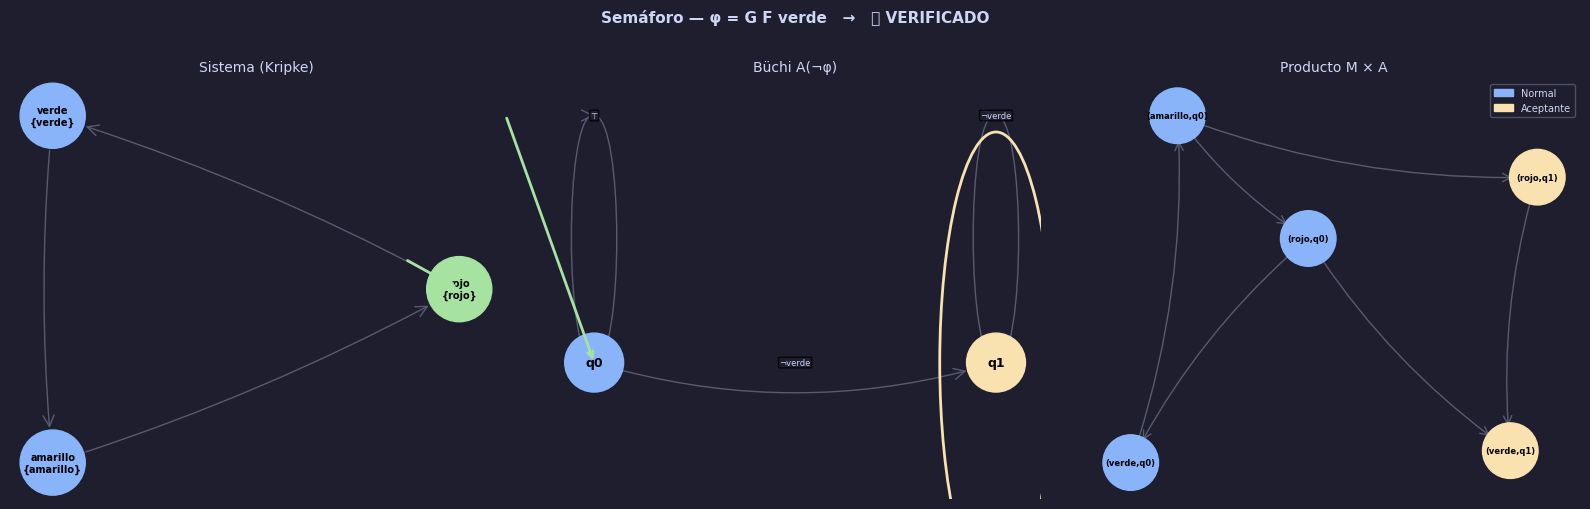

In [16]:
r1 = verify(semaforo, 'G F verde', verbose=False)
visualizar_verificacion(semaforo, r1, titulo='Semáforo — ')

## Visualización — Ejemplo 2: Exclusión Mutua

**$\varphi_1 = \mathbf{G}\,\neg(\text{critica\_A} \wedge \text{critica\_B})$** — seguridad ✅ $\qquad$ **$\varphi_2 = \mathbf{G}\,\mathbf{F}\,\text{critica\_A}$** — vivacidad ❌

En la primera figura el producto no contiene ciclo aceptante, verificando la propiedad de seguridad: el sistema garantiza la exclusión mutua en todos sus comportamientos. En la segunda figura, el Nested DFS encuentra el ciclo de inanición del proceso $A$: el contraejemplo resaltado en rojo corresponde a la traza donde el proceso $B$ obtiene acceso en forma reiterada e indefinida, bloqueando a $A$ para siempre.

/tmp/ipykernel_1355092/1525180854.py:207: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


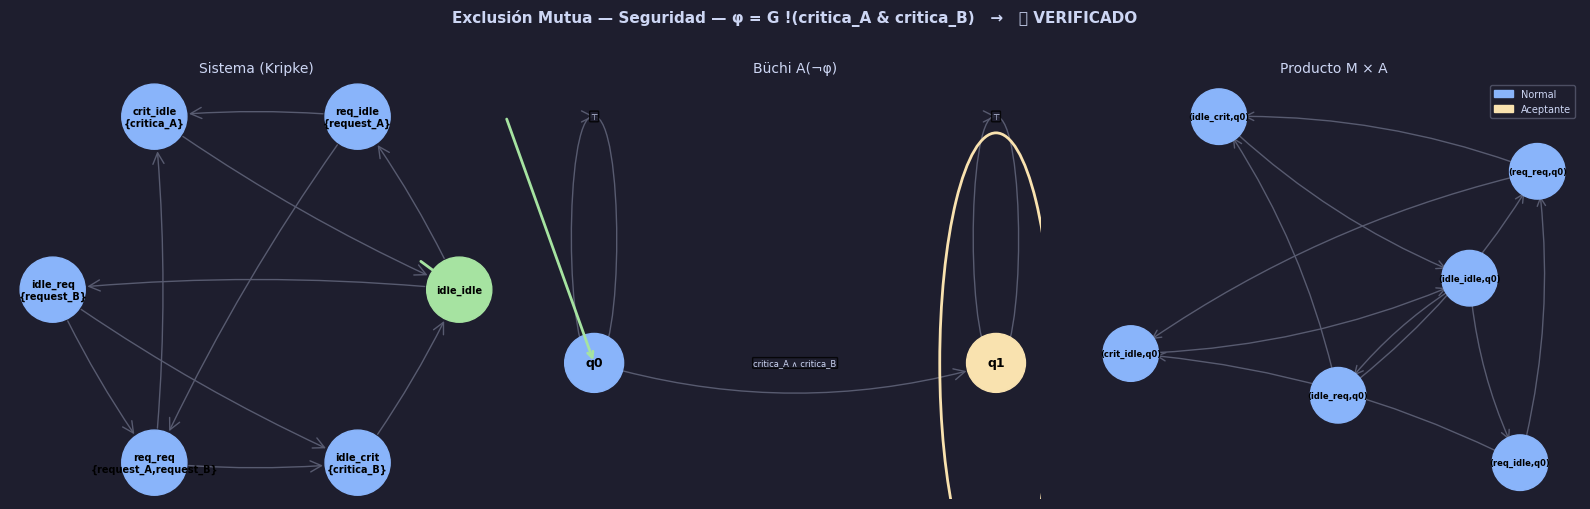

/tmp/ipykernel_1355092/1525180854.py:207: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/home/jorvasquez/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


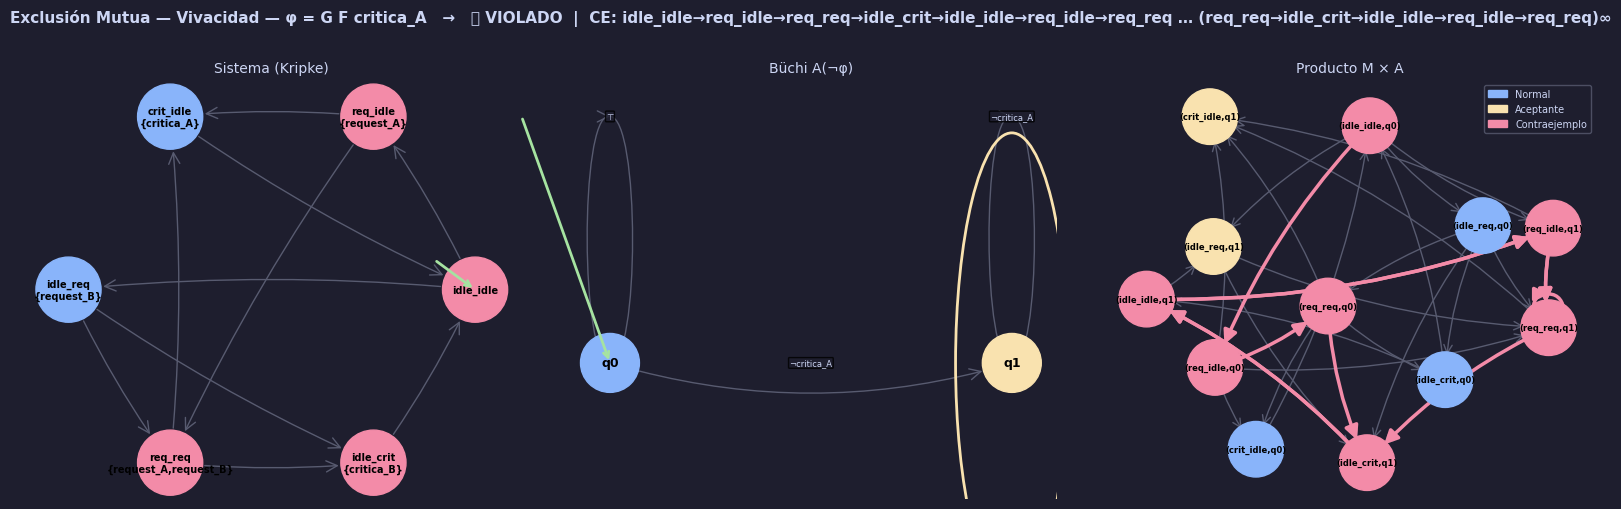

In [17]:
r_seg = verify(exclusion_mutua, 'G !(critica_A & critica_B)', verbose=False)
visualizar_verificacion(exclusion_mutua, r_seg, titulo='Exclusión Mutua — Seguridad — ')

r_viv = verify(exclusion_mutua, 'G F critica_A', verbose=False)
visualizar_verificacion(exclusion_mutua, r_viv, titulo='Exclusión Mutua — Vivacidad — ')

## Visualización — Ejemplo 3: Protocolo con Bug

**$\varphi = \mathbf{G}\,\mathbf{F}\,\text{grant}$** — toda solicitud es eventualmente atendida ❌

La figura muestra cómo el verificador localiza el bug: en el panel del producto, el ciclo $(\text{request}, q_0) \to (\text{deny}, q_0) \to (\text{request}, q_0)$ aparece resaltado en rojo. Este ciclo atraviesa el estado aceptante infinitamente sin que `grant` ocurra nunca. La traza que constituye el contraejemplo es $\text{idle} \to \text{request} \to (\text{deny} \to \text{request})^\omega$, un comportamiento que el testing convencional difícilmente lograría exhibir de forma sistemática.

/tmp/ipykernel_1355092/1525180854.py:207: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


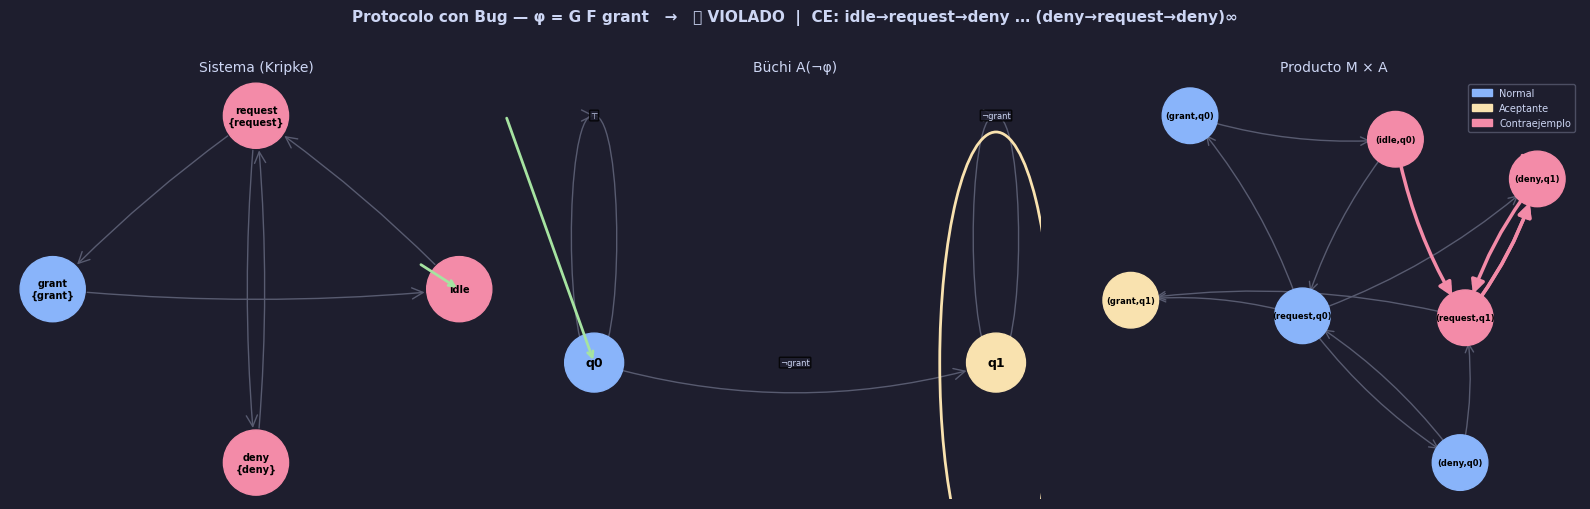

In [18]:
r_bug = verify(protocolo_bug, 'G F grant', verbose=False)
visualizar_verificacion(protocolo_bug, r_bug, titulo='Protocolo con Bug — ')

## Ejemplo 4: Tienda en Línea — Verificación de un Flujo de Compra

### Motivación

Los verificadores de modelos tienen aplicación directa en el diseño de sistemas de software con requisitos de fiabilidad. En este ejemplo se modela el flujo de compra de una tienda en línea como una Estructura de Kripke y se verifica la presencia o ausencia de propiedades de seguridad y vivacidad que un equipo de ingeniería podría incluir como parte de un contrato de comportamiento del sistema.

### Sistema correcto (`tienda_ok`)

El sistema representa un flujo de compra donde el proceso puede terminar exitosamente (`confirmed → shipping → delivered → idle`) o fallar de forma limpia (`processing → failed → idle`). En ambos casos, el sistema siempre regresa al estado inicial:

```
idle → browsing → cart → checkout → processing ──→ confirmed → shipping → delivered
  ↑         ↑                                  ↓                                   ↓
  └─────────┘                                failed ─────────────────────────────→ idle
         (abandona)
```

### Sistema con bug (`tienda_buggy`)

En `tienda_buggy`, el gateway de pagos puede entrar en el estado `gateway_stuck`, desde donde solo hay una transición: hacia sí mismo. El sistema queda bloqueado en un ciclo absorbente:

$$\text{processing} \to \text{gateway\_stuck} \to \text{gateway\_stuck} \to \cdots$$

Este tipo de bug — un ciclo de reintentos sin condición de salida — es característico de fallos de vivacidad en sistemas de integración con servicios externos. Su detección mediante testing convencional requeriría observar el comportamiento asintótico del sistema, lo que en la práctica es inviable.

### Propiedades verificadas

| Propiedad LTL | Semántica | `tienda_ok` | `tienda_buggy` |
|---|---|---|---|
| $\mathbf{G}\,\neg(\text{confirmed} \wedge \text{failed})$ | Exclusión: no confirmado y fallido a la vez | ✅ | ✅ |
| $\mathbf{G}\,\neg(\text{confirmed} \wedge \text{gateway\_stuck})$ | Exclusión: no confirmado y atascado a la vez | ✅ | ✅ |
| $\mathbf{G}\,\mathbf{F}\,\text{idle}$ | El sistema siempre eventualmente reinicia | ✅ | ❌ **BUG** |
| $\mathbf{G}\,\mathbf{F}\,\text{confirmed}$ | Toda sesión eventualmente confirma la compra | ❌ | ❌ |

La propiedad $\mathbf{G}\,\mathbf{F}\,\text{idle}$ actúa como **discriminador formal**: la satisface el sistema correcto y la viola el sistema con bug. El contraejemplo generado apunta con precisión al ciclo `gateway_stuck → gateway_stuck`, localizando matemáticamente el defecto.

In [19]:
# ── Ejemplo 4: Tienda Online ───────────────────────────────────

# Sistema CORRECTO: el pago puede fallar pero siempre limpiamente
tienda_ok = KripkeStructure(
    states=['idle', 'browsing', 'cart', 'checkout',
            'processing', 'confirmed', 'failed', 'shipping', 'delivered'],
    initial='idle',
    transitions=[
        ('idle',        'browsing'),
        ('browsing',    'cart'),
        ('browsing',    'idle'),        # usuario abandona
        ('cart',        'checkout'),
        ('checkout',    'processing'),
        ('processing',  'confirmed'),   # pago exitoso
        ('processing',  'failed'),      # pago fallido — limpiamente
        ('failed',      'idle'),        # regresa al inicio tras fallo
        ('confirmed',   'shipping'),
        ('shipping',    'delivered'),
        ('delivered',   'idle'),
    ],
    labels={
        'idle':       {'idle'},
        'browsing':   {'browsing'},
        'cart':       {'browsing', 'has_cart'},
        'checkout':   {'checkout'},
        'processing': {'processing'},
        'confirmed':  {'confirmed'},
        'failed':     {'failed'},
        'shipping':   {'shipping'},
        'delivered':  {'delivered'},
    }
)

# Sistema CON BUG: el gateway de pagos puede quedar atascado indefinidamente
tienda_buggy = KripkeStructure(
    states=['idle', 'browsing', 'cart', 'checkout',
            'processing', 'confirmed', 'gateway_stuck', 'shipping', 'delivered'],
    initial='idle',
    transitions=[
        ('idle',           'browsing'),
        ('browsing',       'cart'),
        ('browsing',       'idle'),
        ('cart',           'checkout'),
        ('checkout',       'processing'),
        ('processing',     'confirmed'),
        ('processing',     'gateway_stuck'),   # ← BUG: gateway cuelga
        ('gateway_stuck',  'gateway_stuck'),   # bucle infinito
        ('confirmed',      'shipping'),
        ('shipping',       'delivered'),
        ('delivered',      'idle'),
    ],
    labels={
        'idle':          {'idle'},
        'browsing':      {'browsing'},
        'cart':          {'browsing', 'has_cart'},
        'checkout':      {'checkout'},
        'processing':    {'processing'},
        'confirmed':     {'confirmed'},
        'gateway_stuck': {'processing', 'gateway_stuck'},
        'shipping':      {'shipping'},
        'delivered':     {'delivered'},
    }
)

# ── Verificaciones ─────────────────────────────────────────────
print('═' * 60)
print('TIENDA OK — sistema sin bug')
print('═' * 60)

r_ok_safety1 = verify(tienda_ok, 'G !(confirmed & failed)')
assert r_ok_safety1['result'] == True

print()
r_ok_safety2 = verify(tienda_ok, 'G !(confirmed & gateway_stuck)')
assert r_ok_safety2['result'] == True

print()
r_ok_liveness = verify(tienda_ok, 'G F idle')
assert r_ok_liveness['result'] == True

print()
r_ok_strong = verify(tienda_ok, 'G F confirmed')
assert r_ok_strong['result'] == False  # demasiado fuerte: usuario puede no comprar

print()
print('═' * 60)
print('TIENDA BUGGY — sistema con bug en gateway')
print('═' * 60)

print()
r_bug_safety = verify(tienda_buggy, 'G !(confirmed & gateway_stuck)')
assert r_bug_safety['result'] == True

print()
r_bug_liveness = verify(tienda_buggy, 'G F idle')
assert r_bug_liveness['result'] == False  # ← BUG detectado

print()
r_bug_strong = verify(tienda_buggy, 'G F confirmed')
assert r_bug_strong['result'] == False

print()
print('═' * 60)
print('RESUMEN TIENDA')
print('═' * 60)
print(f'  tienda_ok  + G !(confirmed & failed)      → {"✅" if r_ok_safety1["result"] else "❌"}')
print(f'  tienda_ok  + G !(confirmed & g_stuck)     → {"✅" if r_ok_safety2["result"] else "❌"}')
print(f'  tienda_ok  + G F idle                     → {"✅" if r_ok_liveness["result"] else "❌"}')
print(f'  tienda_ok  + G F confirmed                → {"✅" if r_ok_strong["result"] else "❌"}  (esperado ❌)')
print(f'  tienda_bug + G !(confirmed & g_stuck)     → {"✅" if r_bug_safety["result"] else "❌"}')
print(f'  tienda_bug + G F idle                     → {"✅" if r_bug_liveness["result"] else "❌"}  ← BUG')
print(f'  tienda_bug + G F confirmed                → {"✅" if r_bug_strong["result"] else "❌"}  (esperado ❌)')

════════════════════════════════════════════════════════════
TIENDA OK — sistema sin bug
════════════════════════════════════════════════════════════
  φ     = G !(confirmed & failed)
  ¬φ    = F((confirmed & failed))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 9 estados, 11 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

  φ     = G !(confirmed & gateway_stuck)
  ¬φ    = F((confirmed & gateway_stuck))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 9 estados, 11 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

  φ     = G F idle
  ¬φ    = F(G(!idle))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 17 estados, 29 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

  φ     = G F confirmed
  ¬φ    = F(G(!confirmed))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 17 estados, 30 transiciones
  → ❌ VIOL

## Visualización — Ejemplo 4: Tienda en Línea

**$\varphi = \mathbf{G}\,\mathbf{F}\,\text{idle}$** — el sistema siempre eventualmente regresa al estado inicial

La primera figura corresponde a `tienda_ok` ✅: todos los caminos posibles, ya sean exitosos o con fallo limpio, eventualmente regresan a `idle`. El producto $M_{\text{ok}} \times A_{\neg\varphi}$ no contiene ningún ciclo aceptante.

La segunda figura corresponde a `tienda_buggy` ❌: el estado `gateway_stuck` forma un ciclo absorbente del que el sistema no puede escapar. El contraejemplo resaltado en rojo en el panel del producto señala la ruta $\text{processing} \to \text{gateway\_stuck} \to \text{gateway\_stuck} \to \cdots$, demostrando formalmente que existe una ejecución válida del sistema que nunca regresa a `idle`.

/tmp/ipykernel_1355092/1525180854.py:207: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


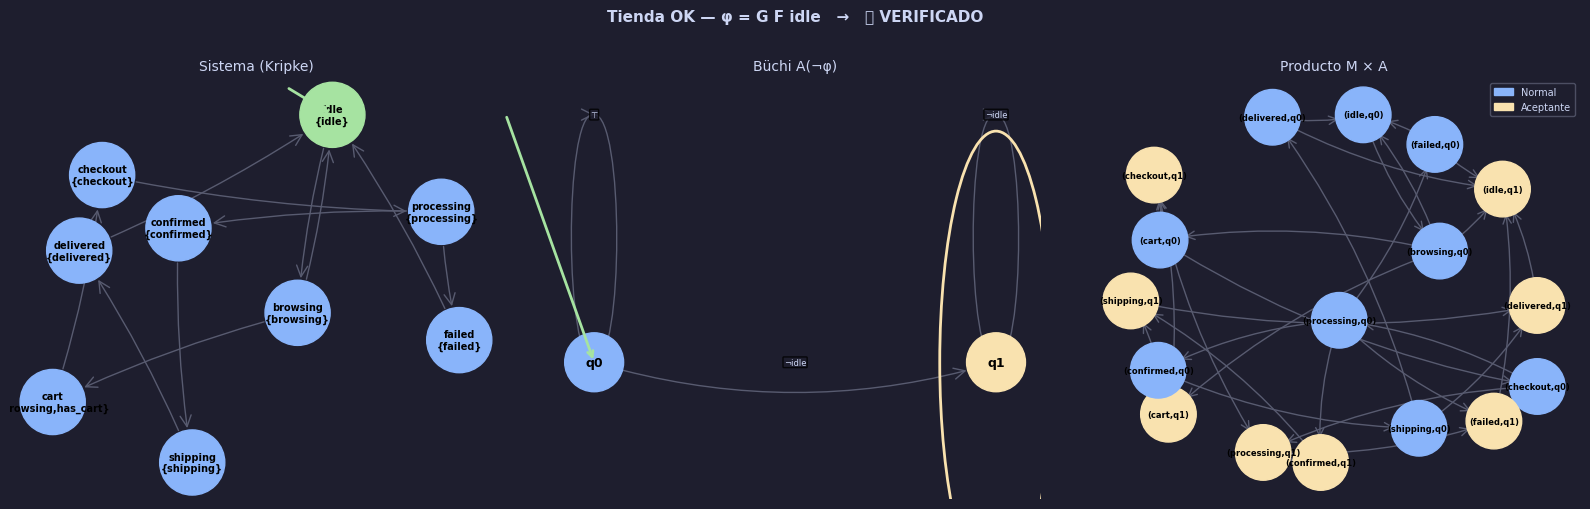

/tmp/ipykernel_1355092/1525180854.py:207: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


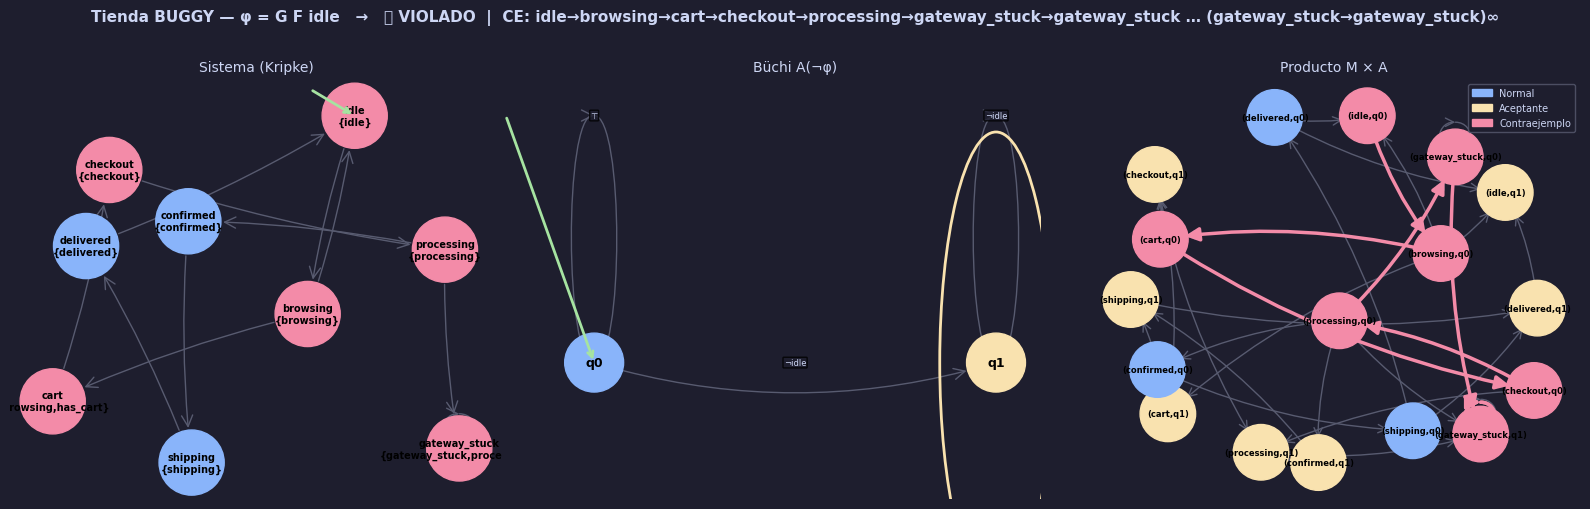

In [20]:
# ── Visualización Ejemplo 4: Tienda — comparación ok vs buggy ──

r_ok_liveness  = verify(tienda_ok,    'G F idle', verbose=False)
r_bug_liveness = verify(tienda_buggy, 'G F idle', verbose=False)

visualizar_verificacion(tienda_ok,    r_ok_liveness,  titulo='Tienda OK — ')
visualizar_verificacion(tienda_buggy, r_bug_liveness, titulo='Tienda BUGGY — ')

## Discusión y Conclusiones

### Alcance del verificador

La implementación cubre el núcleo teórico del *model checking* basado en LTL y Autómatas de Büchi: el algoritmo GPVW, la construcción del producto *on-the-fly* y el Nested DFS son los mismos componentes que emplean herramientas de verificación formal de uso industrial. Los cuatro ejemplos presentados ilustran dos categorías fundamentales de propiedades:

**Propiedades de seguridad** (*safety*): algo malo nunca ocurre. Se especifican con la forma $\mathbf{G}\,\neg\varphi$ y su violación se exhibe con un estado alcanzable. Son relativamente fáciles de verificar por testing, pero el model checker las prueba de forma exhaustiva sobre todos los estados alcanzables.

**Propiedades de vivacidad** (*liveness*): algo bueno ocurre infinitamente. Se especifican con la forma $\mathbf{G}\,\mathbf{F}\,\varphi$ y su violación requiere exhibir un **ciclo** infinito. Este tipo de propiedades son notoriamente difíciles de verificar por testing, ya que requieren razonar sobre comportamientos asintóticos — precisamente el punto fuerte del *model checking* basado en Büchi.

### Relación con herramientas industriales

El verificador reproduce el núcleo algorítmico de las siguientes herramientas de uso académico e industrial:

| Herramienta | Modelo formal | Algoritmo de verificación LTL |
|---|---|---|
| **SPIN** (Bell Labs, 1991) | Procesos concurrentes en Promela | LTL → Büchi vía GPVW + Nested DFS |
| **NuSMV** (CMU / ITC, 2002) | Máquinas de estados simbólicas | LTL + CTL, representación con BDDs |
| **LTL2BA** | Convertidor LTL → Büchi optimizado | Variante optimizada del GPVW |
| **PRISM** (Oxford, 2002) | Sistemas probabilísticos de Markov | LTL sobre cadenas de Markov |

SPIN implementa exactamente el mismo pipeline: $\text{LTL} \xrightarrow{\text{GPVW}} \text{Büchi} \xrightarrow{\times M} \text{Producto} \xrightarrow{\text{DFS}} \text{Ciclo?}$. La diferencia principal es que SPIN opera sobre el espacio de estados comprimido de programas concurrentes escritos en Promela, mientras que este verificador opera sobre Estructuras de Kripke definidas explícitamente.

### Limitaciones

**Explosión de estados:** el tamaño del producto $M \times A$ es $O(|S| \cdot |Q|)$. Para sistemas reales con decenas de variables concurrentes, este espacio crece exponencialmente — el problema conocido como *state space explosion*. Herramientas como SPIN lo mitigan mediante reducción de orden parcial (*partial order reduction*) y representación comprimida del espacio de estados.

**Operadores LTL soportados:** el parser soporta $\mathbf{G}$, $\mathbf{F}$, $\wedge$, $\vee$ y $\neg$. Los operadores $\mathbf{X}$ (siguiente paso) y $\mathbf{U}$ (hasta que) no están implementados, aunque el algoritmo GPVW los soportaría con extensiones menores en las reglas de expansión.

**Totalidad de la relación de transición:** el verificador asume que todo estado del Kripke tiene al menos un sucesor, lo que garantiza la existencia de ejecuciones infinitas. Estados sin sucesores requerirían un tratamiento especial para definir trazas infinitas sobre ellos.

### Posibles extensiones

El verificador podría extenderse en las siguientes direcciones:

- **Soporte completo de LTL:** añadir los operadores $\mathbf{X}$ y $\mathbf{U}$ al parser y al expand de GPVW
- **Reducción de orden parcial:** implementar técnicas de *partial order reduction* para mitigar la explosión de estados en sistemas con concurrencia
- **Representación simbólica:** reemplazar los grafos explícitos por BDDs (*Binary Decision Diagrams*), lo que permitiría escalar a sistemas con miles de variables de estado
- **Trazas con valores:** extender el contraejemplo con los valores concretos de las proposiciones atómicas en cada paso, para facilitar el diagnóstico en sistemas con muchas proposiciones

### Conclusión

Este proyecto demuestra que los **Autómatas de Büchi** no son únicamente un objeto matemático abstracto, sino el mecanismo computacional central de una de las técnicas de verificación formal más poderosas de las ciencias de la computación. La cadena teórica:

$$\text{LTL} \;\xrightarrow{\text{GPVW}}\; \text{GNBA} \;\xrightarrow{\text{desgeneralización}}\; \text{NBA} \;\xrightarrow{\times M}\; \text{Producto} \;\xrightarrow{\text{Nested DFS}}\; \text{¿Ciclo aceptante?}$$

conecta directamente la teoría de autómatas sobre palabras infinitas, la lógica temporal y la verificación de software, constituyendo un ejemplo concreto de la unidad profunda entre teoría formal y práctica de ingeniería.